In [2]:
import pandas as pd

data = pd.read_csv("data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
data.shape

(7043, 21)

In [8]:
# Drop customerID - not a predictive feature
data = data.drop(["customerID"], axis=1)

# TotalCharges has some blank strings - convert to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Drop rows with missing TotalCharges (only ~11 rows)
data.dropna(subset=["TotalCharges"], inplace=True)

# Convert target variable: Churn Yes=1, No=0
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# Remove spaces from column names
data.rename(columns=lambda x: x.replace(' ', '_'), inplace=True)

print(f"Dataset shape after cleaning: {data.shape}")
data.head()

Dataset shape after cleaning: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [9]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = data.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

data.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


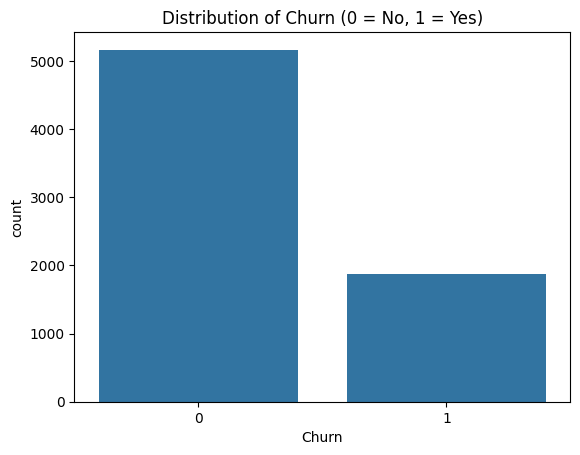

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=data)
plt.title("Distribution of Churn (0 = No, 1 = Yes)")
plt.show()

In [11]:
pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [13]:
print(data["Churn"].value_counts())
print(f"\nChurn rate: {data['Churn'].mean():.2%}")

Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.58%


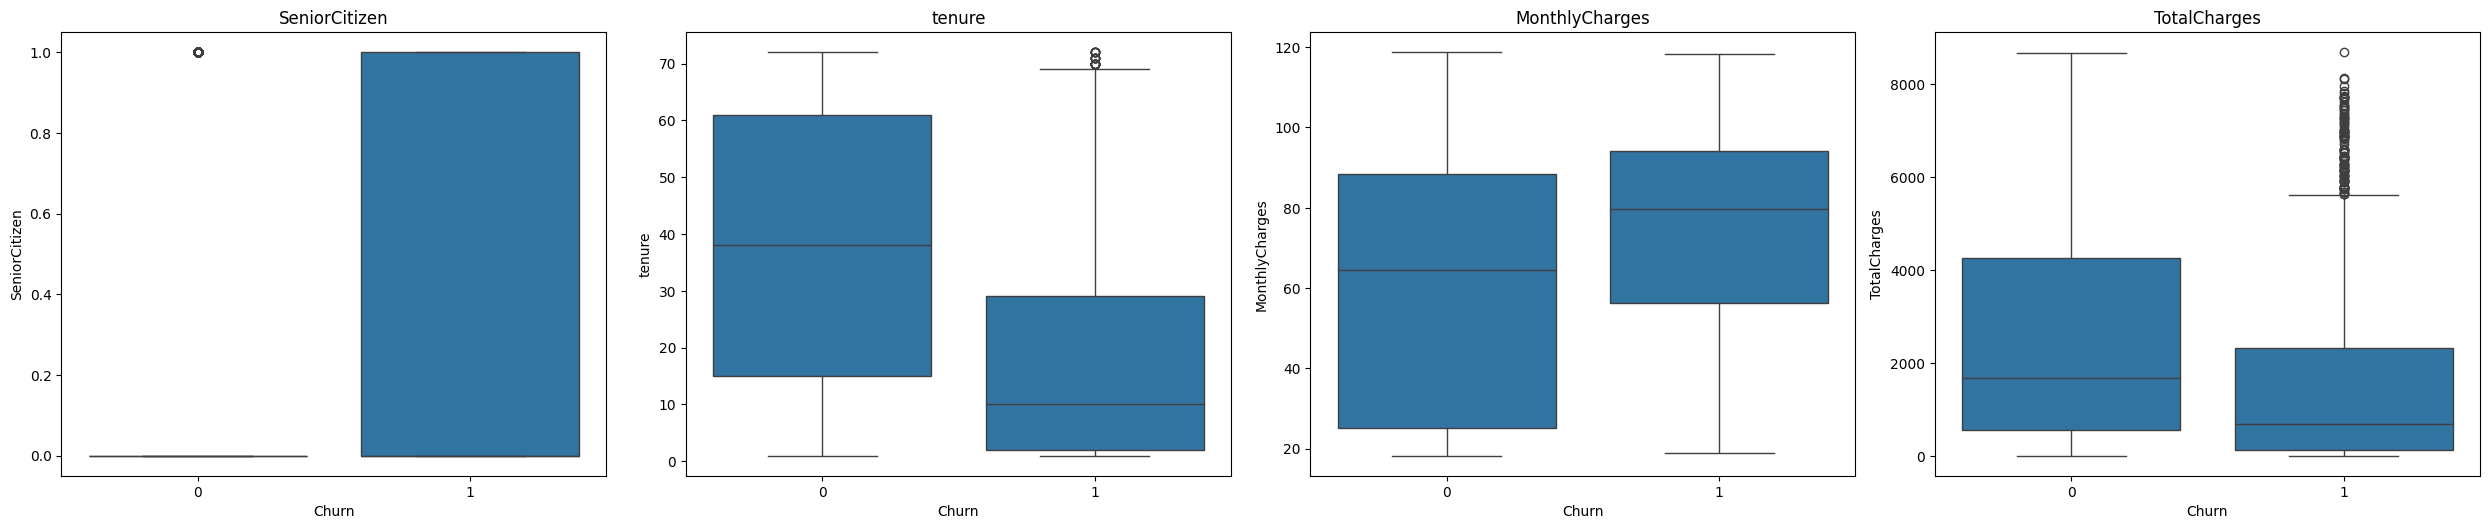

In [17]:
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "Churn"]

dims = (3, 4)
f, axes = plt.subplots(dims[0], dims[1], figsize=(25, 15))
axis_i, axis_j = 0, 0

for col in numeric_cols:
    if axis_i < dims[0]:
        sns.boxplot(x=data["Churn"].astype(int), y=data[col], ax=axes[axis_i, axis_j])
        axes[axis_i, axis_j].set_title(col)
        axis_j += 1
        if axis_j == dims[1]:
            axis_i += 1
            axis_j = 0

for i in range(axis_i, dims[0]):
    start_j = axis_j if i == axis_i else 0
    for j in range(start_j, dims[1]):
        axes[i, j].set_visible(False)

plt.tight_layout()
plt.show()

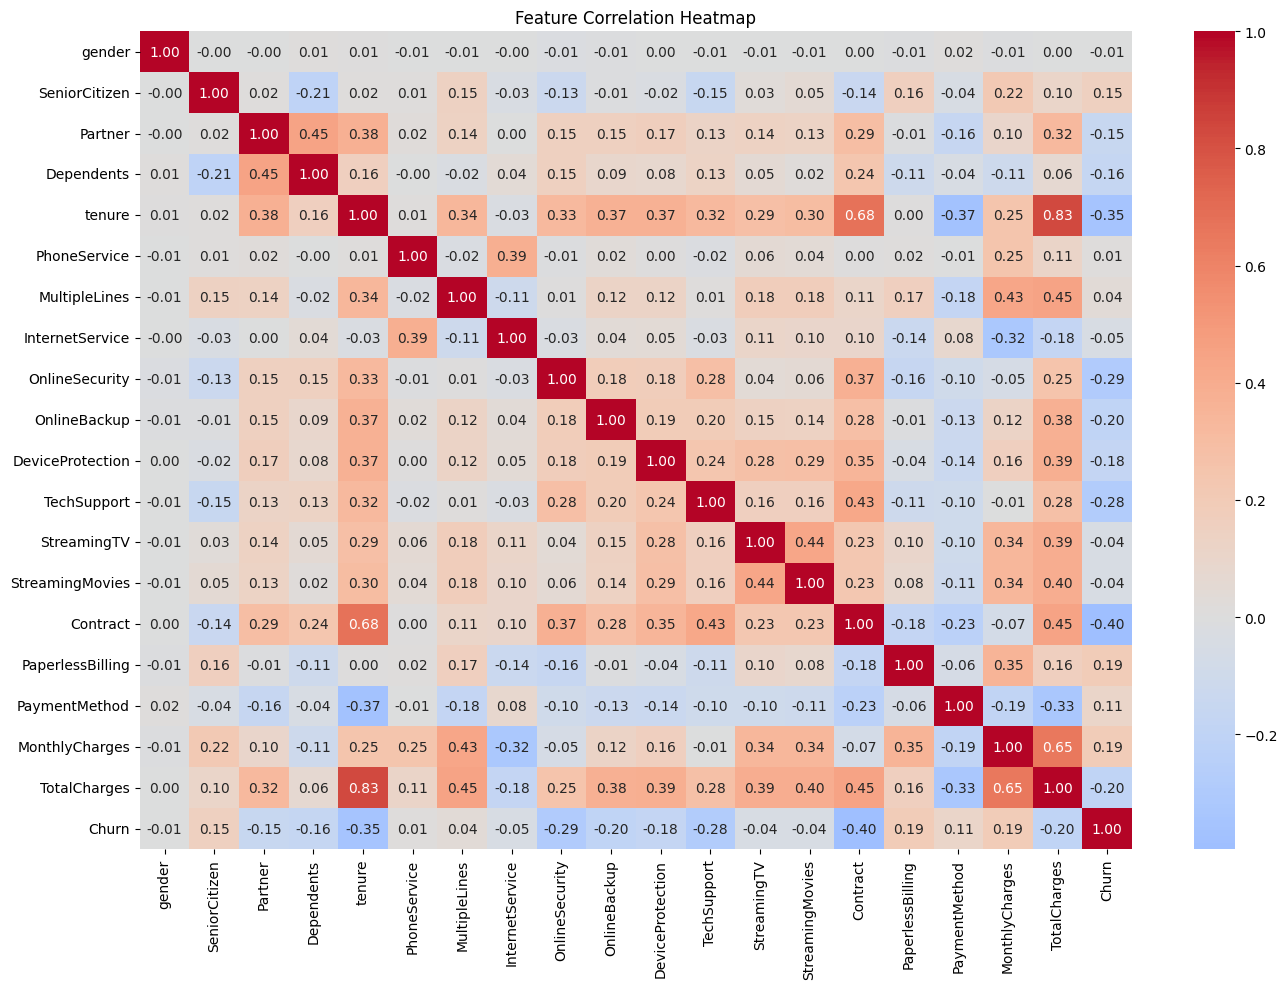

In [18]:
plt.figure(figsize=(14, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [19]:
data.isna().any()

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool

In [20]:
from sklearn.model_selection import train_test_split

X = data.drop(["Churn"], axis=1)
y = data["Churn"]

# Split out the training data (60%)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)

# Split the remaining data equally into validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

Training set:   4219 samples
Validation set: 1406 samples
Test set:       1407 samples


In [23]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time

C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
pip install mlflow scikit-learn cloudpickle

  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached protobuf-6.33.5-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   --------- ------------------------------ 2.4/10.2 MB 15.0 MB/s eta 0:00:01
   ----------------------- ---------------- 6.0/10.2 MB 16.1 MB/s eta 0:00:01
   ------------------------------------ --- 9.2/10.2 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 10.2/10.2 MB 14.4 MB/s  0:00:00
   ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
   -------------------------------------- - 2.9/3.0 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------- 3.0/3.0 MB 12.4 MB/s  0:00:00
   ---------------------------------------- 0.0/1.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.67.0 requires protobuf!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0.dev0,>=3.20.2, but you have protobuf 6.33.5 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.5 which is incompatible.
grpcio-status 1.70.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.5 which is incompatible.
proto-plus 1.26.0 requires protobuf<6.0.0dev,>=3.19.0, but you have protobuf 6.33.5 which is incompatible.
streamlit 1.43.2 requires protobuf<6,>=3.20, but you have protobuf 6.33.5 which is incompatible.


   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   ------------------------------------- -- 26/28 [mlflow-skinny]
   -------

In [24]:
import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import numpy as np
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env
import cloudpickle
import time

# Wrapper class to return probabilities instead of binary predictions
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]

with mlflow.start_run(run_name="untuned_random_forest"):
    n_estimators = 10
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=np.random.RandomState(123))
    model.fit(X_train, y_train)

    # predict_proba returns [prob_negative, prob_positive], so slice with [:, 1]
    predictions_test = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, predictions_test)
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_metric("auc", auc_score)
    print(f"Random Forest AUC: {auc_score:.4f}")

    wrappedModel = SklearnModelWrapper(model)
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))

    conda_env = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            "cloudpickle=={}".format(cloudpickle.__version__),
            "scikit-learn=={}".format(sklearn.__version__),
        ],
        additional_conda_channels=None,
    )
    mlflow.pyfunc.log_model(
        "random_forest_model",
        python_model=wrappedModel,
        conda_env=conda_env,
        signature=signature,
    )

C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/03/13 15:22:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/13 15:22:55 INFO mlflow.store.db.utils: Updating database tables
C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will caus

Random Forest AUC: 0.7835


C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\pyfunc\__init__.py:3304: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


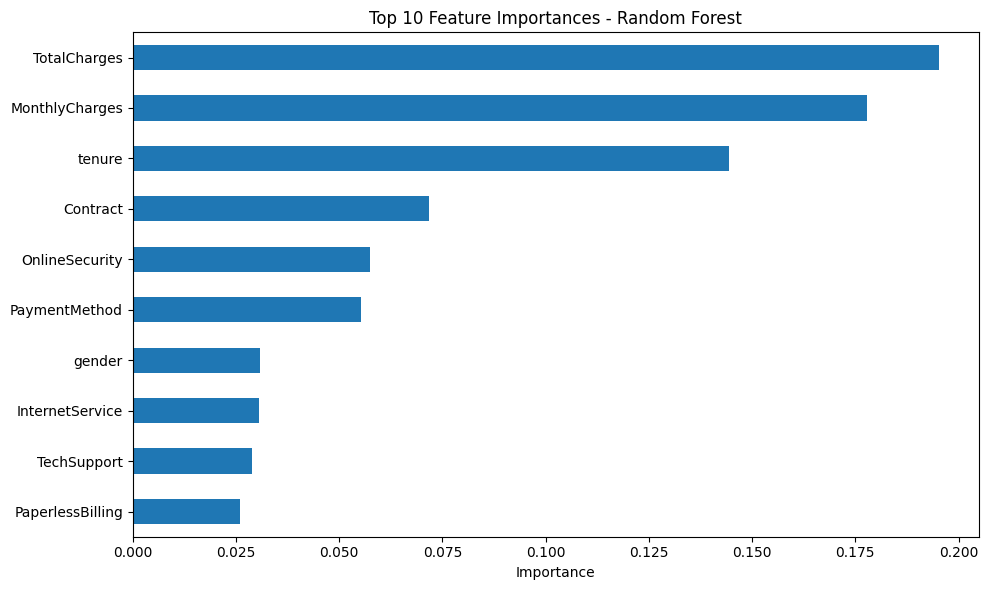

In [25]:
feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=X_train.columns.tolist(),
    columns=["importance"],
)
feature_importances.sort_values("importance", ascending=False)
# Visualize top features
top_features = feature_importances.sort_values("importance", ascending=True).tail(10)
top_features.plot(kind="barh", legend=False, figsize=(10, 6))
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [28]:
from xgboost import XGBClassifier

class XGBModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]

with mlflow.start_run(run_name="xgboost_baseline"):
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=123,
        eval_metric="logloss",
    )
    xgb_model.fit(X_train, y_train)

    xgb_predictions_test = xgb_model.predict_proba(X_test)[:, 1]
    xgb_auc_score = roc_auc_score(y_test, xgb_predictions_test)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_metric("auc", xgb_auc_score)
    print(f"XGBoost AUC: {xgb_auc_score:.4f}")

    wrappedXGB = XGBModelWrapper(xgb_model)
    xgb_signature = infer_signature(X_train, wrappedXGB.predict(None, X_train))

    conda_env_xgb = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            "cloudpickle=={}".format(cloudpickle.__version__),
            "xgboost",
            "scikit-learn=={}".format(sklearn.__version__),
        ],
        additional_conda_channels=None,
    )
    mlflow.pyfunc.log_model(
        "xgboost_model",
        python_model=wrappedXGB,
        conda_env=conda_env_xgb,
        signature=xgb_signature,
    )

C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes miss

XGBoost AUC: 0.8465


C:\Users\varup\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\pyfunc\__init__.py:3304: UserWarning: An input example was not provided when logging the model. To ensure the model signature functions correctly, specify the `input_example` parameter. See https://mlflow.org/docs/latest/model/signatures.html#model-input-example for more details about the benefits of using input_example.
  color_warning(


In [27]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [29]:
print(f"Random Forest AUC: {auc_score:.4f}")
print(f"XGBoost AUC:       {xgb_auc_score:.4f}")
print(f"\nBest model: {'XGBoost' if xgb_auc_score > auc_score else 'Random Forest'}")

Random Forest AUC: 0.7835
XGBoost AUC:       0.8465

Best model: XGBoost


In [30]:
best_run_name = "xgboost_baseline" if xgb_auc_score > auc_score else "untuned_random_forest"
best_model_artifact = "xgboost_model" if xgb_auc_score > auc_score else "random_forest_model"

run_id = mlflow.search_runs(
    filter_string=f'tags.mlflow.runName = "{best_run_name}"'
).iloc[0].run_id

model_name = "customer_churn"
model_version = mlflow.register_model(f"runs:/{run_id}/{best_model_artifact}", model_name)

Successfully registered model 'customer_churn'.
2026/03/13 15:25:26 WARNING mlflow.tracking._model_registry.fluent: Run with id 1724a474d1504769bcc304fec7b49d74 has no artifacts at artifact path 'xgboost_model', registering model based on models:/m-aaaf893aa6624cb1afa8bf2bbb30e01d instead
Created version '1' of model 'customer_churn'.


In [31]:

# Registering the model takes a few seconds
time.sleep(15)

In [32]:

from mlflow.tracking import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage="Production",
)

C:\Users\varup\AppData\Local\Temp\ipykernel_5152\2559535096.py:4: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


<ModelVersion: aliases=[], creation_timestamp=1773429926529, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1773429961876, metrics=None, model_id=None, name='customer_churn', params=None, run_id='1724a474d1504769bcc304fec7b49d74', run_link=None, source='models:/m-aaaf893aa6624cb1afa8bf2bbb30e01d', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>

In [33]:
model_prod = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

print(f"Production Model AUC: {roc_auc_score(y_test, model_prod.predict(X_test)):.4f}")

Production Model AUC: 0.8465
